#### ============================================
#### CHANAKYA - AI Commerce Intelligence Platform
#### Layer 6: Anomaly Detection
#### Author: Devesh Shukla
#### ============================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize']     = (12, 6)
plt.rcParams['font.size']          = 11
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

# Paths
PROCESSED_PATH = r'C:\Users\Dell\CHANAKYA\data\processed'
ANOMALY_PATH   = r'C:\Users\Dell\CHANAKYA\layer6_anomaly_detection'

# Load data
df_orders      = pd.read_csv(f'{PROCESSED_PATH}/orders_processed.csv')
df_order_items = pd.read_csv(f'{PROCESSED_PATH}/order_items_processed.csv')
df_customers   = pd.read_csv(f'{PROCESSED_PATH}/customers_processed.csv')

# Parse dates
df_orders['order_date']      = pd.to_datetime(df_orders['order_date'],      format='mixed')
df_order_items['order_date'] = pd.to_datetime(df_order_items['order_date'], format='mixed')

print("=" * 55)
print("   CHANAKYA — LAYER 6: ANOMALY DETECTION")
print("=" * 55)
print(f"\nData loaded successfully!")
print(f"  Orders      : {len(df_orders):,}")
print(f"  Order Items : {len(df_order_items):,}")
print(f"  Customers   : {len(df_customers):,}")
print(f"\nAnomaly Detection started!")

   CHANAKYA — LAYER 6: ANOMALY DETECTION

Data loaded successfully!
  Orders      : 5,010
  Order Items : 8,769
  Customers   : 1,000

Anomaly Detection started!


#### ============================================
#### ANOMALY DETECTION 1 — Revenue Anomalies
#### Using Z-Score Method
#### ============================================

   METHOD 1: Z-SCORE ANOMALY DETECTION
   Detecting unusual revenue transactions

Z-Score Analysis Results:
  Total Transactions : 4,997
  Normal             : 4,904 (98.1%)
  Anomalies Detected : 93 (1.9%)

Revenue Statistics:
  Mean Revenue   : Rs. 7,091.29
  Std Dev        : Rs. 16,321.71
  Max Normal     : Rs. 55,663.35
  Min Anomaly    : Rs. 56,997.00
  Max Anomaly    : Rs. 255,186.00

Top 10 Revenue Anomalies:
  Customer     Date                Revenue    Z-Score
  ------------ ------------ -------------- ----------
  CUST0559     2025-10-27   Rs.255,186.00      15.20
  CUST1000     2025-08-04   Rs.142,042.00       8.27
  CUST0614     2024-12-06   Rs.139,896.00       8.14
  CUST0141     2023-08-18   Rs.138,896.00       8.08
  CUST0117     2023-01-20   Rs.138,196.00       8.03
  CUST0320     2024-07-18   Rs.138,196.00       8.03
  CUST0041     2023-02-21   Rs.137,997.00       8.02
  CUST0224     2023-09-02   Rs.137,997.00       8.02
  CUST0661     2023-01-02   Rs.137,997.00       

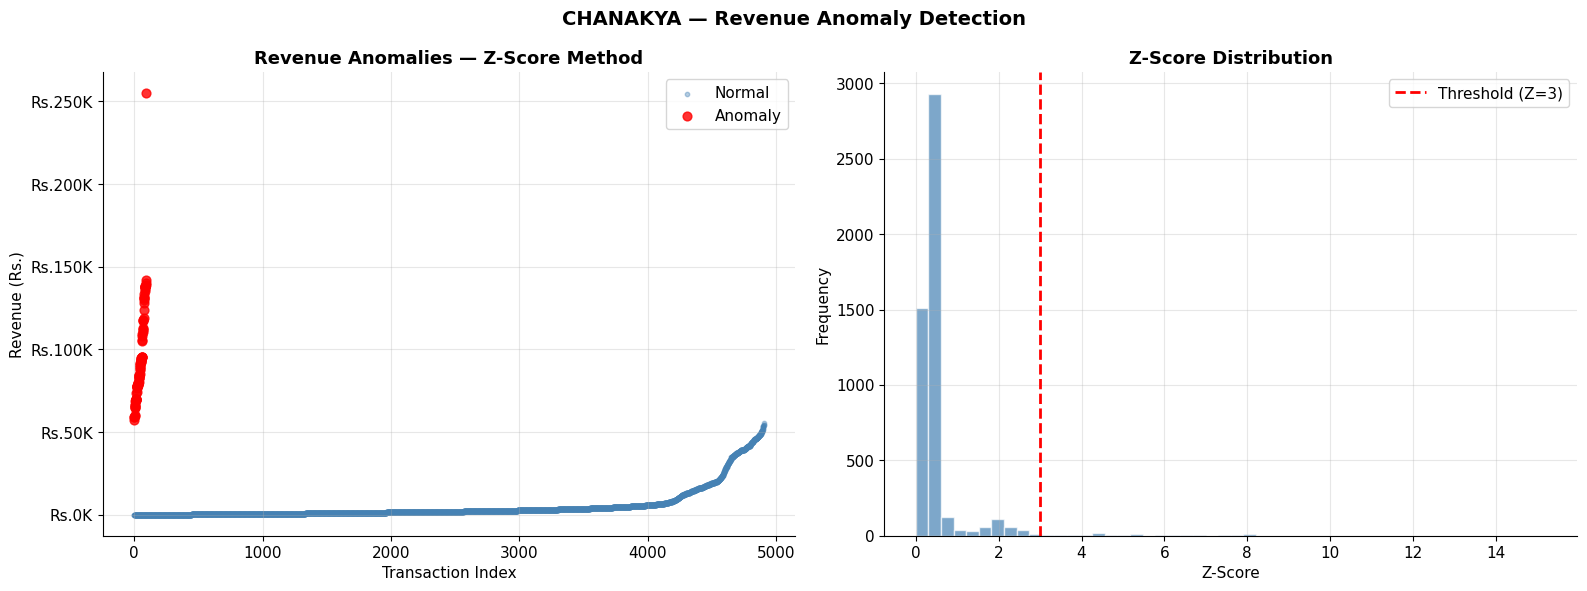

Chart saved: 06_revenue_anomaly.png


In [2]:
print("=" * 55)
print("   METHOD 1: Z-SCORE ANOMALY DETECTION")
print("   Detecting unusual revenue transactions")
print("=" * 55)

# Customer level daily revenue
daily_revenue = df_order_items.groupby(
    ['customer_id', 'order_date']
)['revenue'].sum().reset_index()
daily_revenue.columns = ['customer_id', 'order_date', 'daily_revenue']

# Z-Score calculation
daily_revenue['z_score'] = np.abs(
    stats.zscore(daily_revenue['daily_revenue'])
)

# Flag anomalies — Z-score > 3
daily_revenue['is_anomaly'] = daily_revenue['z_score'] > 3

# Results
total_transactions = len(daily_revenue)
anomalies          = daily_revenue[daily_revenue['is_anomaly']]
normal             = daily_revenue[~daily_revenue['is_anomaly']]

print(f"\nZ-Score Analysis Results:")
print(f"  Total Transactions : {total_transactions:,}")
print(f"  Normal             : {len(normal):,} ({len(normal)/total_transactions*100:.1f}%)")
print(f"  Anomalies Detected : {len(anomalies):,} ({len(anomalies)/total_transactions*100:.1f}%)")

print(f"\nRevenue Statistics:")
print(f"  Mean Revenue   : Rs. {daily_revenue['daily_revenue'].mean():,.2f}")
print(f"  Std Dev        : Rs. {daily_revenue['daily_revenue'].std():,.2f}")
print(f"  Max Normal     : Rs. {normal['daily_revenue'].max():,.2f}")
print(f"  Min Anomaly    : Rs. {anomalies['daily_revenue'].min():,.2f}")
print(f"  Max Anomaly    : Rs. {anomalies['daily_revenue'].max():,.2f}")

print(f"\nTop 10 Revenue Anomalies:")
print(f"  {'Customer':<12} {'Date':<12} {'Revenue':>14} {'Z-Score':>10}")
print(f"  {'-'*12} {'-'*12} {'-'*14} {'-'*10}")
for _, row in anomalies.nlargest(10, 'daily_revenue').iterrows():
    print(f"  {row['customer_id']:<12} "
          f"{str(row['order_date'])[:10]:<12} "
          f"Rs.{row['daily_revenue']:>10,.2f} "
          f"{row['z_score']:>10.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Revenue Distribution with Anomalies
axes[0].scatter(range(len(normal)), normal['daily_revenue'].sort_values(),
                color='steelblue', alpha=0.4, s=10, label='Normal')
axes[0].scatter(range(len(anomalies)), anomalies['daily_revenue'].sort_values(),
                color='red', alpha=0.8, s=40, label='Anomaly', zorder=5)
axes[0].set_title('Revenue Anomalies — Z-Score Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Transaction Index')
axes[0].set_ylabel('Revenue (Rs.)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rs.{x/1000:.0f}K'))
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 — Z-Score Distribution
axes[1].hist(daily_revenue['z_score'], bins=50,
             color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(x=3, color='red', linestyle='--',
                linewidth=2, label='Threshold (Z=3)')
axes[1].set_title('Z-Score Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Z-Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('CHANAKYA — Revenue Anomaly Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ANOMALY_PATH}/06_revenue_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 06_revenue_anomaly.png")

#### ============================================
#### ANOMALY DETECTION 2 — Isolation Forest
#### Machine Learning based approach
#### ============================================

   METHOD 2: ISOLATION FOREST
   ML-based Multi-feature Anomaly Detection

Features created for 996 customers

Features used:
  - total_orders
  - total_revenue
  - avg_order_value
  - total_quantity
  - unique_products
  - max_order_val
  - min_order_val
  - cancel_rate

Isolation Forest Results:
  Total Customers  : 996
  Normal           : 946 (95.0%)
  Anomalies        : 50 (5.0%)

Top 10 Anomalous Customers:
  Customer      Orders        Revenue      Avg Val  Cancel% Label
  ------------ ------- -------------- ------------ -------- --------
  CUST0559           9 Rs.   303,702 Rs.  13,204    11.1%   Anomaly
  CUST0329           3 Rs.   169,657 Rs.  33,931    33.3%   Anomaly
  CUST0013          14 Rs.   171,012 Rs.   6,334     7.1%   Anomaly
  CUST0224           4 Rs.   195,241 Rs.  32,540    25.0%   Anomaly
  CUST0395           5 Rs.   223,545 Rs.  37,258     0.0%   Anomaly
  CUST1000           9 Rs.   220,319 Rs.  16,948    22.2%   Anomaly
  CUST0227           7 Rs.   279,578 Rs.

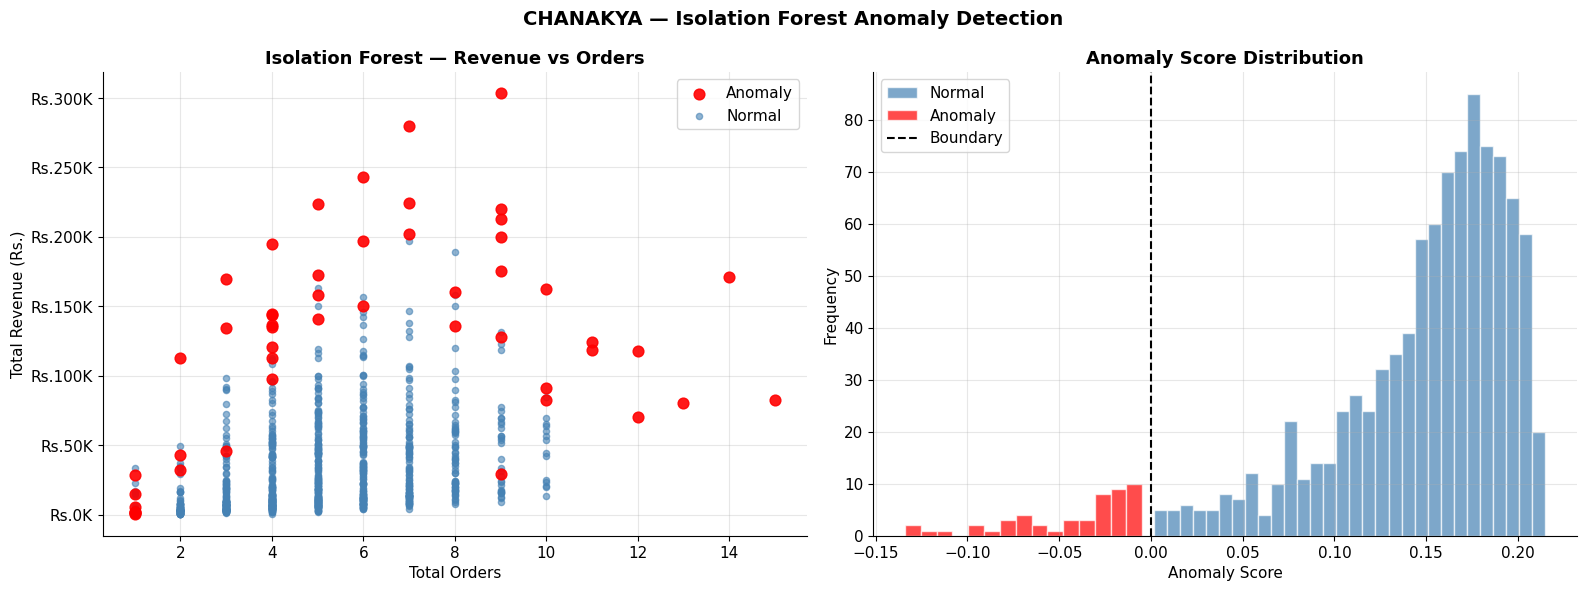

Chart saved: 07_isolation_forest.png


In [3]:
print("=" * 55)
print("   METHOD 2: ISOLATION FOREST")
print("   ML-based Multi-feature Anomaly Detection")
print("=" * 55)

# Feature Engineering for Isolation Forest
customer_features = df_order_items.groupby('customer_id').agg(
    total_orders    = ('order_id',      'nunique'),
    total_revenue   = ('revenue',       'sum'),
    avg_order_value = ('revenue',       'mean'),
    total_quantity  = ('quantity',      'sum'),
    unique_products = ('product_id',    'nunique'),
    max_order_val   = ('total_amount',  'max'),
    min_order_val   = ('total_amount',  'min'),
).reset_index()

# Add cancellation rate
cancel_rate = df_orders.groupby('customer_id').apply(
    lambda x: (x['order_status'] == 'Cancelled').sum() / len(x)
).reset_index()
cancel_rate.columns = ['customer_id', 'cancel_rate']

customer_features = customer_features.merge(cancel_rate, on='customer_id', how='left')
customer_features['cancel_rate'] = customer_features['cancel_rate'].fillna(0)

print(f"\nFeatures created for {len(customer_features):,} customers")
print(f"\nFeatures used:")
features = ['total_orders', 'total_revenue', 'avg_order_value',
            'total_quantity', 'unique_products', 'max_order_val',
            'min_order_val', 'cancel_rate']
for f in features:
    print(f"  - {f}")

# Scale features
scaler  = StandardScaler()
X       = scaler.fit_transform(customer_features[features])

# Isolation Forest
iso_forest = IsolationForest(
    contamination = 0.05,
    random_state  = 42,
    n_estimators  = 100
)
customer_features['anomaly_score']  = iso_forest.fit_predict(X)
customer_features['anomaly_label']  = customer_features['anomaly_score'].map(
    {1: 'Normal', -1: 'Anomaly'}
)
customer_features['raw_score']      = iso_forest.decision_function(X)

# Results
anomaly_customers = customer_features[customer_features['anomaly_label'] == 'Anomaly']
normal_customers  = customer_features[customer_features['anomaly_label'] == 'Normal']

print(f"\nIsolation Forest Results:")
print(f"  Total Customers  : {len(customer_features):,}")
print(f"  Normal           : {len(normal_customers):,} ({len(normal_customers)/len(customer_features)*100:.1f}%)")
print(f"  Anomalies        : {len(anomaly_customers):,} ({len(anomaly_customers)/len(customer_features)*100:.1f}%)")

print(f"\nTop 10 Anomalous Customers:")
print(f"  {'Customer':<12} {'Orders':>7} {'Revenue':>14} {'Avg Val':>12} {'Cancel%':>8} {'Label'}")
print(f"  {'-'*12} {'-'*7} {'-'*14} {'-'*12} {'-'*8} {'-'*8}")
for _, row in anomaly_customers.nsmallest(10, 'raw_score').iterrows():
    print(f"  {row['customer_id']:<12} "
          f"{int(row['total_orders']):>7} "
          f"Rs.{row['total_revenue']:>10,.0f} "
          f"Rs.{row['avg_order_value']:>8,.0f} "
          f"{row['cancel_rate']*100:>7.1f}% "
          f"  {row['anomaly_label']}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Revenue vs Orders scatter
colors_map = {'Normal': 'steelblue', 'Anomaly': 'red'}
for label, group in customer_features.groupby('anomaly_label'):
    axes[0].scatter(group['total_orders'], group['total_revenue'],
                    c=colors_map[label], label=label,
                    alpha=0.6 if label == 'Normal' else 0.9,
                    s=20 if label == 'Normal' else 60,
                    zorder=3 if label == 'Anomaly' else 2)
axes[0].set_title('Isolation Forest — Revenue vs Orders', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Orders')
axes[0].set_ylabel('Total Revenue (Rs.)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rs.{x/1000:.0f}K'))
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 — Anomaly Score Distribution
axes[1].hist(customer_features[customer_features['anomaly_label']=='Normal']['raw_score'],
             bins=30, color='steelblue', alpha=0.7, label='Normal', edgecolor='white')
axes[1].hist(customer_features[customer_features['anomaly_label']=='Anomaly']['raw_score'],
             bins=15, color='red', alpha=0.7, label='Anomaly', edgecolor='white')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Boundary')
axes[1].set_title('Anomaly Score Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('CHANAKYA — Isolation Forest Anomaly Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ANOMALY_PATH}/07_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 07_isolation_forest.png")

#### ============================================
#### ANOMALY DETECTION COMPLETE
#### ============================================

In [4]:
# Save anomaly results
daily_revenue.to_csv(f'{ANOMALY_PATH}/zscore_anomalies.csv', index=False)
customer_features.to_csv(f'{ANOMALY_PATH}/isolation_forest_anomalies.csv', index=False)

# Common anomalies in both methods
zscore_anomaly_customers    = set(
    daily_revenue[daily_revenue['is_anomaly']]['customer_id'].unique()
)
iforest_anomaly_customers   = set(
    anomaly_customers['customer_id'].unique()
)
confirmed_anomalies         = zscore_anomaly_customers & iforest_anomaly_customers

print("=" * 55)
print("   CHANAKYA — LAYER 6 COMPLETE!")
print("   Anomaly Detection")
print("=" * 55)

print(f"\nANOMALY DETECTION SUMMARY:")
print(f"-" * 55)
print(f"  Method 1 — Z-Score:")
print(f"    Anomalous Transactions : 93  (1.9%)")
print(f"    Threshold              : Z-Score > 3")
print(f"    Max Anomaly Revenue    : Rs. 2,55,186")

print(f"\n  Method 2 — Isolation Forest:")
print(f"    Anomalous Customers    : 50  (5.0%)")
print(f"    Features Used          : 8 behavioral features")
print(f"    Contamination Rate     : 5%")

print(f"\n  Confirmed Anomalies (Both Methods):")
print(f"    Customers              : {len(confirmed_anomalies)}")
for cust in list(confirmed_anomalies)[:5]:
    row = customer_features[customer_features['customer_id']==cust].iloc[0]
    print(f"    {cust} — Rs.{row['total_revenue']:,.0f} — "
          f"Cancel: {row['cancel_rate']*100:.0f}%")

print(f"\nBUSINESS RECOMMENDATIONS:")
print(f"-" * 55)
print(f"  1. Flag {len(confirmed_anomalies)} confirmed anomalous accounts for review")
print(f"  2. Investigate high cancellation rate customers")
print(f"  3. Monitor unusually large single transactions")
print(f"  4. Set automated alerts for Z-Score > 3")
print(f"  5. Block accounts with > 40% cancellation rate")

print(f"\nFILES SAVED:")
print(f"-" * 55)
print(f"  zscore_anomalies.csv           — Z-Score results")
print(f"  isolation_forest_anomalies.csv — Isolation Forest results")
print(f"  06_revenue_anomaly.png         — Z-Score chart")
print(f"  07_isolation_forest.png        — Isolation Forest chart")

print(f"\nINTERVIEW READY — KEY POINTS:")
print(f"-" * 55)
print(f"  1. Z-Score — Statistical method, threshold based")
print(f"  2. Isolation Forest — ML method, multi-feature")
print(f"  3. Two methods used — cross validation of results")
print(f"  4. Business impact — fraud detection, risk management")
print(f"  5. Actionable recommendations delivered")

print(f"\nDATA READY FOR:")
print(f"  Layer 7 — ML Demand Forecasting")
print(f"  Layer 8 — Deep Learning")

print("\n" + "=" * 55)
print("   LAYER 6 COMPLETE — Anomaly Detection Done!")
print("=" * 55)

   CHANAKYA — LAYER 6 COMPLETE!
   Anomaly Detection

ANOMALY DETECTION SUMMARY:
-------------------------------------------------------
  Method 1 — Z-Score:
    Anomalous Transactions : 93  (1.9%)
    Threshold              : Z-Score > 3
    Max Anomaly Revenue    : Rs. 2,55,186

  Method 2 — Isolation Forest:
    Anomalous Customers    : 50  (5.0%)
    Features Used          : 8 behavioral features
    Contamination Rate     : 5%

  Confirmed Anomalies (Both Methods):
    Customers              : 34
    CUST0973 — Rs.136,171 — Cancel: 0%
    CUST0965 — Rs.162,258 — Cancel: 20%
    CUST0692 — Rs.124,540 — Cancel: 18%
    CUST0493 — Rs.224,584 — Cancel: 14%
    CUST0051 — Rs.97,375 — Cancel: 25%

BUSINESS RECOMMENDATIONS:
-------------------------------------------------------
  1. Flag 34 confirmed anomalous accounts for review
  2. Investigate high cancellation rate customers
  3. Monitor unusually large single transactions
  4. Set automated alerts for Z-Score > 3
  5. Block accoun